# EfficientNet-B3 + Fourier — teljes teszthalmaz kiértékelő notebook

Ez a notebook **nem tanít újra modellt**.  
A mentett `best_efficientnetb3_fourier.pth` checkpointot tölti be, majd a megadott BRISC testhalmazon kiértékeli.

Tartalmazza:

- checkpoint betöltés,
- automatikus test osztálymappa felismerés,
- osztálynév normalizálás,
- teljes test evaluation,
- accuracy / precision / recall / F1 összesítés,
- classification report,
- confusion matrix,
- normalizált confusion matrix,
- képenkénti predikciós táblázat,
- hibásan klasszifikált képek táblázata,
- hibás példák vizualizálása.

A modell architektúrája a feltöltött EfficientNet-B3 + Fourier tanítási notebook alapján készült.

In [1]:
# Colab Drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.fft

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

print("Torch:", torch.__version__)
print("CUDA elérhető:", torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA elérhető: True


In [3]:
# =========================
# BEÁLLÍTÁSOK
# =========================

EFFICIENTNET_CKPT = "/content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/checkpoints/best_efficientnetb3_fourier.pth"

TEST_DIR = "/content/drive/MyDrive/Brain MRI/dataset/Test"

OUT_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL"

# EfficientNet-B3 tanítási notebookban 300x300 volt használva.
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_WORKERS = 2

SEED = 42

# A modell tanításánál használt kanonikus osztálysorrend.
# Ezt NEM rendezzük abc szerint, mert a checkpoint kimenete ehhez az indexeléshez tartozik.
CANONICAL_CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Checkpoint:", EFFICIENTNET_CKPT)
print("Test folder:", TEST_DIR)
print("Output folder:", OUT_DIR)

Device: cuda
Checkpoint: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/checkpoints/best_efficientnetb3_fourier.pth
Test folder: /content/drive/MyDrive/Brain MRI/dataset/Test
Output folder: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL


In [4]:
# =========================
# ÚTVONALAK ELLENŐRZÉSE
# =========================

if not os.path.exists(EFFICIENTNET_CKPT):
    raise FileNotFoundError(f"Checkpoint nem található: {EFFICIENTNET_CKPT}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test mappa nem található: {TEST_DIR}")

print("Checkpoint létezik:", os.path.exists(EFFICIENTNET_CKPT))
print("Test mappa létezik:", os.path.exists(TEST_DIR))

print("\nTest mappa tartalma:")
for item in sorted(os.listdir(TEST_DIR)):
    p = os.path.join(TEST_DIR, item)
    if os.path.isdir(p):
        n = len([
            f for f in os.listdir(p)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"))
        ])
        print(f"  {item:25s} -> {n} kép")

Checkpoint létezik: True
Test mappa létezik: True

Test mappa tartalma:
  glioma                    -> 603 kép
  meningioma                -> 436 kép
  notumor                   -> 389 kép
  pituitary                 -> 429 kép


In [5]:
# =========================
# OSZTÁLYNÉV NORMALIZÁLÁS
# =========================
# A test mappák nevei lehetnek pl.:
# glioma, glioma_tumor, meningioma, meningioma_tumor,
# no_tumor, notumor, pituitary, pituitary_tumor stb.

def normalize_folder_name(name: str) -> str:
    s = name.lower().strip()
    s = s.replace("-", "_").replace(" ", "_")

    if "glioma" in s:
        return "glioma"
    if "meningioma" in s:
        return "meningioma"
    if "pituitary" in s:
        return "pituitary"
    if s in ["no_tumor", "notumor", "no_tumour", "notumour", "normal", "healthy"]:
        return "no_tumor"
    if "no" in s and ("tumor" in s or "tumour" in s):
        return "no_tumor"

    return s

folder_rows = []

for folder_name in sorted(os.listdir(TEST_DIR)):
    folder_path = os.path.join(TEST_DIR, folder_name)
    if os.path.isdir(folder_path):
        canonical = normalize_folder_name(folder_name)
        folder_rows.append({
            "folder_name": folder_name,
            "canonical_label": canonical,
            "folder_path": folder_path
        })

folder_df = pd.DataFrame(folder_rows)
display(folder_df)

detected_labels = sorted(folder_df["canonical_label"].unique().tolist())
print("Detected canonical labels:", detected_labels)

missing = [c for c in CANONICAL_CLASS_NAMES if c not in detected_labels]
extra = [c for c in detected_labels if c not in CANONICAL_CLASS_NAMES]

if missing:
    print("FIGYELEM: ezek a kanonikus osztályok hiányoznak a test mappából:", missing)

if extra:
    print("FIGYELEM: ismeretlen plusz osztálymappák:", extra)

CLASS_NAMES = CANONICAL_CLASS_NAMES
label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
label_map_inv = {idx: name for name, idx in label_map.items()}

print("Használt modell-osztálysorrend:", CLASS_NAMES)
print("Label map:", label_map)

,folder_name,canonical_label,folder_path
0,glioma,glioma,/content/drive/MyDrive/Brain MRI/dataset/Test/...
1,meningioma,meningioma,/content/drive/MyDrive/Brain MRI/dataset/Test/...
2,notumor,no_tumor,/content/drive/MyDrive/Brain MRI/dataset/Test/...
3,pituitary,pituitary,/content/drive/MyDrive/Brain MRI/dataset/Test/...


Detected canonical labels: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Használt modell-osztálysorrend: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Label map: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [6]:
# =========================
# TEST DATAFRAME ÉPÍTÉSE
# =========================

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

rows = []

for _, r in folder_df.iterrows():
    folder_name = r["folder_name"]
    canonical_label = r["canonical_label"]
    folder_path = r["folder_path"]

    if canonical_label not in label_map:
        print(f"Kihagyva, mert nem ismert osztály: {folder_name} -> {canonical_label}")
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(valid_exts):
            rows.append({
                "image_path": os.path.join(folder_path, fname),
                "folder_label": folder_name,
                "label": canonical_label,
                "label_idx": label_map[canonical_label]
            })

df_test = pd.DataFrame(rows)

if len(df_test) == 0:
    raise RuntimeError("Nem találtam képeket a test mappában. Ellenőrizd a TEST_DIR útvonalat és az almappákat.")

print("Összes test kép:", len(df_test))
print("\nOsztályeloszlás:")
display(df_test["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame("count"))

csv_path = os.path.join(OUT_DIR, "test_file_list.csv")
df_test.to_csv(csv_path, index=False)
print("Test fájllista mentve:", csv_path)

display(df_test.head())

Összes test kép: 1857

Osztályeloszlás:


,count
label,
glioma,603
meningioma,436
no_tumor,389
pituitary,429


Test fájllista mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_file_list.csv


,image_path,folder_label,label,label_idx
0,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
1,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
2,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
3,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0
4,/content/drive/MyDrive/Brain MRI/dataset/Test/...,glioma,glioma,0


In [7]:
# =========================
# TRANSFORM ÉS DATASET
# =========================
# Testhalmazon nincs augmentáció, csak resize + normalize.

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BrainTumorTestDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row["image_path"]
        label_idx = int(row["label_idx"])

        img = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label_idx, image_path

test_dataset = BrainTumorTestDataset(df_test, transform=eval_transforms)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Test dataset méret:", len(test_dataset))
print("Batch-ek száma:", len(test_loader))

Test dataset méret: 1857
Batch-ek száma: 117


In [8]:
# =========================
# MODELL ARCHITEKTÚRA
# EfficientNet-B3 + Fourier
# A tanítási notebook szerkezete alapján:
# features -> Conv2d(1536,384) -> SpectralConv2d(384,384) -> BN -> ReLU -> Dropout -> Pool -> Linear(384,4)
# =========================

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1=8, modes2=8):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)

        self.w1_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w1_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))

    def forward(self, x):
        batchsize = x.shape[0]

        w1 = torch.complex(self.w1_real, self.w1_imag)
        w2 = torch.complex(self.w2_real, self.w2_imag)

        x_f32 = x.float()
        x_ft = torch.fft.rfft2(x_f32)

        m1 = min(self.modes1, x_ft.size(-2))
        m2 = min(self.modes2, x_ft.size(-1))

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x_f32.size(-2),
            x_f32.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :m1, :m2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, :m1, :m2],
            w1[:, :, :m1, :m2]
        )

        out_ft[:, :, -m1:, :m2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, -m1:, :m2],
            w2[:, :, :m1, :m2]
        )

        x = torch.fft.irfft2(out_ft, s=(x_f32.size(-2), x_f32.size(-1)))
        return x.to(x_f32.dtype)


def create_efficientnetb3_fourier(num_classes=4):
    # weights=None, hogy ne próbáljon internetről ImageNet súlyokat letölteni.
    # A checkpoint úgyis betölti a teljes betanított modellt.
    base = models.efficientnet_b3(weights=None)

    class EfficientNetB3Fourier(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.features = backbone.features

            self.reduce = nn.Conv2d(1536, 384, kernel_size=1)

            self.fourier = nn.Sequential(
                SpectralConv2d(384, 384, modes1=8, modes2=8),
                nn.BatchNorm2d(384),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30)
            )

            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.dropout = nn.Dropout(0.25)
            self.classifier = nn.Linear(384, num_classes)

        def forward(self, x):
            x = self.features(x)
            x = self.reduce(x)
            x = self.fourier(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            x = self.classifier(x)
            return x

    return EfficientNetB3Fourier(base).to(device)

model = create_efficientnetb3_fourier(num_classes=len(CLASS_NAMES))
print(model.__class__.__name__)

EfficientNetB3Fourier


In [9]:
# =========================
# CHECKPOINT BETÖLTÉSE
# =========================

def load_checkpoint_safely(path, device):
    try:
        ckpt = torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        ckpt = torch.load(path, map_location=device)
    except Exception:
        ckpt = torch.load(path, map_location=device)
    return ckpt

ckpt = load_checkpoint_safely(EFFICIENTNET_CKPT, device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

# DataParallel esetén module. prefix eltávolítása
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

if "classifier.weight" in state_dict:
    print("Checkpoint classifier.weight shape:", tuple(state_dict["classifier.weight"].shape))
    print("Notebook num_classes:", len(CLASS_NAMES))

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Checkpoint betöltve:", EFFICIENTNET_CKPT)

if missing:
    print("\nHiányzó kulcsok:")
    for k in missing:
        print(" ", k)

if unexpected:
    print("\nVáratlan kulcsok:")
    for k in unexpected:
        print(" ", k)

if len(missing) == 0 and len(unexpected) == 0:
    print("Sikeres strict-kompatibilis betöltés: nincs hiányzó vagy váratlan kulcs.")
else:
    print("\nFIGYELEM: volt hiányzó vagy váratlan kulcs. Ha sok ilyen van, akkor az architektúra nem egyezik a checkpointtal.")

model.eval()

Checkpoint classifier.weight shape: (4, 384)
Notebook num_classes: 4
Checkpoint betöltve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/checkpoints/best_efficientnetb3_fourier.pth
Sikeres strict-kompatibilis betöltés: nincs hiányzó vagy váratlan kulcs.


EfficientNetB3Fourier(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2d

In [10]:
# =========================
# TEST KIÉRTÉKELÉS
# =========================

y_true = []
y_pred = []
y_prob = []
image_paths = []

use_amp = torch.cuda.is_available()

with torch.no_grad():
    for images, labels, paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        image_paths.extend(paths)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predikciók elkészültek.")
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

Testing:   0%|          | 0/117 [00:00<?, ?it/s]

Predikciók elkészültek.
y_true shape: (1857,)
y_pred shape: (1857,)
y_prob shape: (1857, 4)


In [11]:
# =========================
# ÖSSZESÍTŐ METRIKÁK
# =========================

test_acc = accuracy_score(y_true, y_pred)

summary_df = pd.DataFrame([{
    "Model": "EfficientNet-B3 + Fourier",
    "Test Accuracy": test_acc,
    "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Number of test images": len(y_true)
}])

display(summary_df)

summary_csv = os.path.join(OUT_DIR, "test_summary_metrics.csv")
summary_df.to_csv(summary_csv, index=False)
print("Mentve:", summary_csv)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Number of test images
0,EfficientNet-B3 + Fourier,0.946688,0.945085,0.954741,0.948132,0.950284,0.946688,0.946484,1857


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_summary_metrics.csv


In [12]:
# =========================
# CLASSIFICATION REPORT
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_csv = os.path.join(OUT_DIR, "test_classification_report.csv")
report_df.to_csv(report_csv, index=True)
print("Mentve:", report_csv)

,precision,recall,f1-score,support
glioma,0.994329,0.872305,0.929329,603.000000
meningioma,0.893305,0.979358,0.934354,436.000000
no_tumor,0.908873,0.974293,0.940447,389.000000
pituitary,0.983834,0.993007,0.988399,429.000000
accuracy,0.946688,0.946688,0.946688,0.946688
macro avg,0.945085,0.954741,0.948132,1857.000000
weighted avg,0.950284,0.946688,0.946484,1857.000000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_classification_report.csv


In [13]:
# =========================
# PAPER-READY METRIKA TÁBLÁZAT
# =========================

prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    zero_division=0
)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "EfficientNet-B3 + Fourier",
        "Class": cls,
        "Precision": round(float(prec[i]), 4),
        "Recall": round(float(rec[i]), 4),
        "F1-Score": round(float(f1[i]), 4),
        "Support": int(support[i]),
        "Accuracy": ""
    })

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": ""
})

rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": round(float(test_acc), 4)
})

results_table_df = pd.DataFrame(rows)
display(results_table_df)

results_csv = os.path.join(OUT_DIR, "test_results_table.csv")
results_table_df.to_csv(results_csv, index=False)
print("Mentve:", results_csv)

,Model,Class,Precision,Recall,F1-Score,Support,Accuracy
0,EfficientNet-B3 + Fourier,glioma,0.9943,0.8723,0.9293,603,
1,EfficientNet-B3 + Fourier,meningioma,0.8933,0.9794,0.9344,436,
2,EfficientNet-B3 + Fourier,no_tumor,0.9089,0.9743,0.9404,389,
3,EfficientNet-B3 + Fourier,pituitary,0.9838,0.9930,0.9884,429,
4,,Macro Avg,0.9451,0.9547,0.9481,1857,
5,,Weighted Avg,0.9503,0.9467,0.9465,1857,0.9467


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_results_table.csv


,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,526,41,34,2
True: meningioma,1,427,4,4
True: no_tumor,2,7,379,1
True: pituitary,0,3,0,426


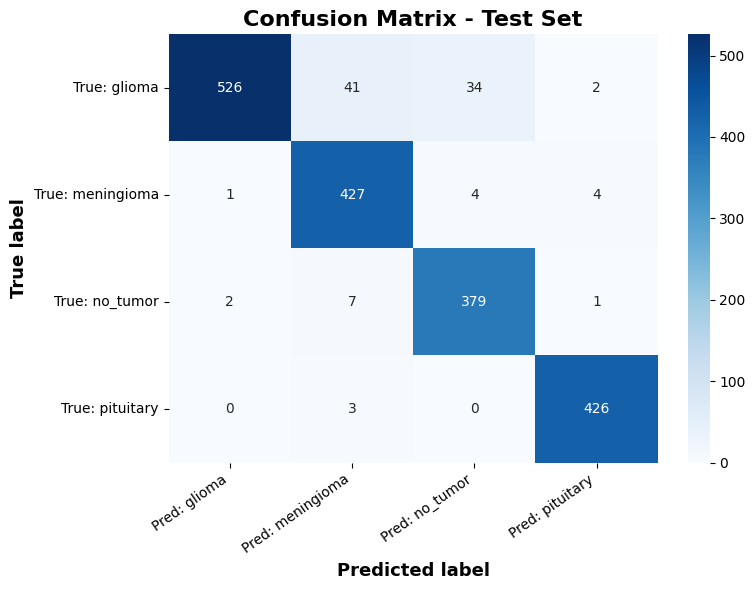

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_confusion_matrix_counts.png


In [14]:
# =========================
# CONFUSION MATRIX - DARABSZÁM
# =========================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES)))
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_df)

cm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_counts.csv")
cm_df.to_csv(cm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)
plt.title("Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_png = os.path.join(OUT_DIR, "test_confusion_matrix_counts.png")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_csv)
print("Kép mentve:", cm_png)

,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,0.872305,0.067993,0.056385,0.003317
True: meningioma,0.002294,0.979358,0.009174,0.009174
True: no_tumor,0.005141,0.017995,0.974293,0.002571
True: pituitary,0.000000,0.006993,0.000000,0.993007


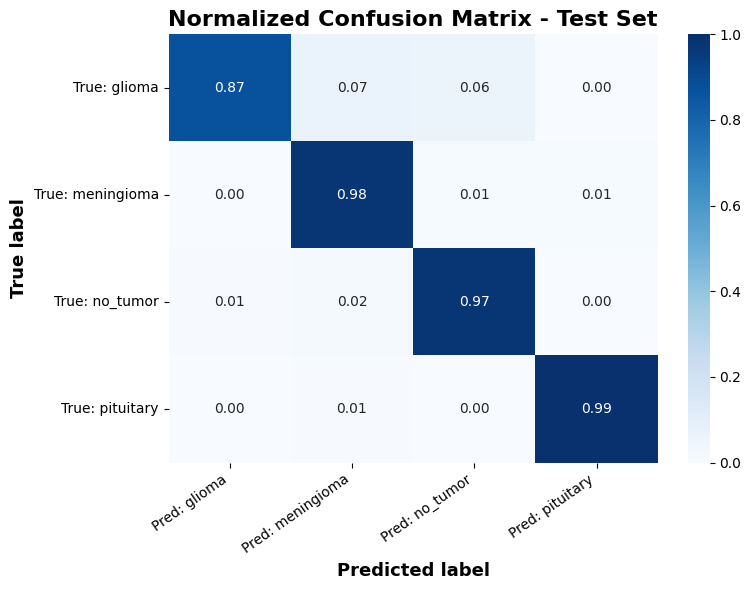

CSV mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.csv
Kép mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_confusion_matrix_normalized.png


In [15]:
# =========================
# NORMALIZÁLT CONFUSION MATRIX
# =========================

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_norm_df)

cm_norm_csv = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_csv, index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    vmin=0,
    vmax=1
)
plt.title("Normalized Confusion Matrix - Test Set", fontsize=16, fontweight="bold")
plt.ylabel("True label", fontsize=13, fontweight="bold")
plt.xlabel("Predicted label", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_png = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.png")
plt.savefig(cm_norm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV mentve:", cm_norm_csv)
print("Kép mentve:", cm_norm_png)

In [16]:
# =========================
# KÉPENKÉNTI PREDIKCIÓS TÁBLÁZAT
# =========================

pred_rows = []

for i in range(len(y_true)):
    row = {
        "image_path": image_paths[i],
        "true_idx": int(y_true[i]),
        "pred_idx": int(y_pred[i]),
        "true_label": label_map_inv[int(y_true[i])],
        "predicted_label": label_map_inv[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "confidence": float(np.max(y_prob[i]))
    }

    for j, cname in enumerate(CLASS_NAMES):
        row[f"prob_{cname}"] = float(y_prob[i][j])

    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)

display(pred_df.head(20))

pred_csv = os.path.join(OUT_DIR, "test_predictions_per_image.csv")
pred_df.to_csv(pred_csv, index=False)
print("Mentve:", pred_csv)

,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
0,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000142,1.728535e-06,0.000039
1,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000031,1.251698e-06,0.000027
2,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000149,3.278255e-06,0.000086
3,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000046,3.457069e-06,0.000017
4,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000042,8.046627e-06,0.000017
5,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000052,1.072884e-06,0.000315
6,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000030,5.960464e-08,0.000026
7,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,1.000000,1.000000,0.000102,3.159046e-06,0.000067
8,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.996582,0.996582,0.001681,1.524687e-04,0.001571
9,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,0,glioma,glioma,True,0.999512,0.999512,0.000194,1.949072e-05,0.000238


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_predictions_per_image.csv


In [17]:
# =========================
# HIBÁSAN KLASSZIFIKÁLT KÉPEK
# =========================

wrong_df = pred_df[pred_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values(by="confidence", ascending=False)

print("Hibás predikciók száma:", len(wrong_df), "/", len(pred_df))
display(wrong_df.head(50))

wrong_csv = os.path.join(OUT_DIR, "test_misclassified_images.csv")
wrong_df.to_csv(wrong_csv, index=False)
print("Mentve:", wrong_csv)

Hibás predikciók száma: 99 / 1857


,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
488,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999512,0.000079,0.999512,0.000521,0.000049
489,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999512,0.000216,0.999512,0.000071,0.000329
485,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999023,0.000214,0.999023,0.000369,0.000214
486,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.999023,0.000338,0.999023,0.000527,0.000095
559,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.998535,0.001193,0.000149,0.998535,0.000275
527,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998535,0.000764,0.998535,0.000472,0.000188
557,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.998535,0.000716,0.000111,0.998535,0.000532
419,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,2,glioma,no_tumor,False,0.998535,0.000582,0.000652,0.998535,0.000105
490,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998047,0.000309,0.998047,0.001361,0.000153
525,/content/drive/MyDrive/Brain MRI/dataset/Test/...,0,1,glioma,meningioma,False,0.998047,0.000921,0.998047,0.000917,0.000228


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/test_misclassified_images.csv


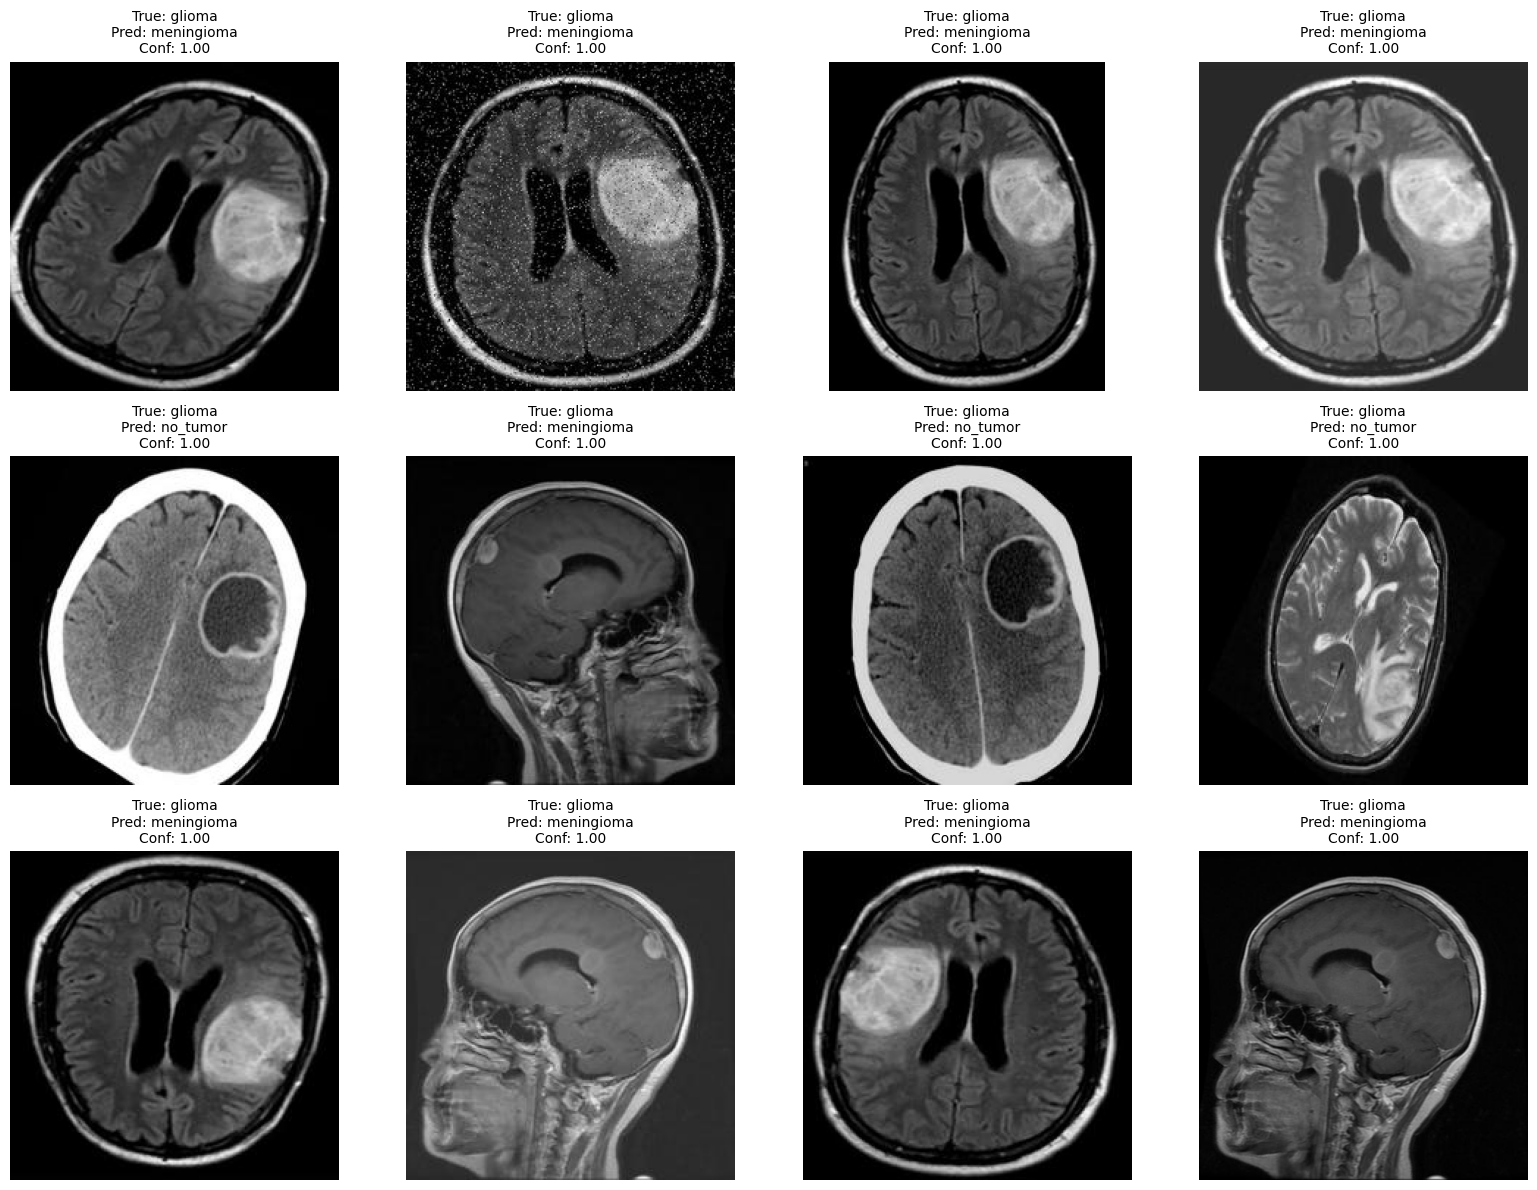

Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL/misclassified_examples.png


In [18]:
# =========================
# HIBÁS PÉLDÁK VIZUALIZÁLÁSA
# =========================

def show_misclassified_examples(wrong_df, max_images=12):
    if len(wrong_df) == 0:
        print("Nincs hibás klasszifikáció.")
        return

    sample_df = wrong_df.head(max_images).copy()
    n = len(sample_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "misclassified_examples.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Mentve:", out_path)

show_misclassified_examples(wrong_df, max_images=12)

In [19]:
# =========================
# ÖSSZES EREDMÉNY LISTÁZÁSA
# =========================

print("Kiértékelés kész.")
print("Eredmények mappája:", OUT_DIR)

print("\nLétrehozott fájlok:")
for f in sorted(os.listdir(OUT_DIR)):
    print(" -", f)

Kiértékelés kész.
Eredmények mappája: /content/drive/MyDrive/Brain MRI/FNO_clas/EfficientNetB3_Fourier_final/test_evaluation_FULL

Létrehozott fájlok:
 - misclassified_examples.png
 - test_classification_report.csv
 - test_confusion_matrix_counts.csv
 - test_confusion_matrix_counts.png
 - test_confusion_matrix_normalized.csv
 - test_confusion_matrix_normalized.png
 - test_file_list.csv
 - test_misclassified_images.csv
 - test_predictions_per_image.csv
 - test_results_table.csv
 - test_summary_metrics.csv
